Name: Suyog Bastakoti

Uni Id: 2407093

Cell 1 — Importing all libraries

In [7]:
# Cell 1: Import all libraries

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import time
import random
import warnings
warnings.filterwarnings('ignore')

# TensorFlow / Keras — must be imported BEFORE setting seeds
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Set seeds AFTER importing tf
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# Scikit-learn
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

2026-05-07 16:53:16.875561: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778172797.125285      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778172797.200794      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778172797.762143      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778172797.762189      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778172797.762191      57 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


Cell 2 — Define Dataset Paths & Class Names

In [8]:
import os

TRAIN_DIR = '/kaggle/input/datasets/nodoubttome/skin-cancer9-classesisic/Skin cancer ISIC The International Skin Imaging Collaboration/Train'
TEST_DIR  = '/kaggle/input/datasets/nodoubttome/skin-cancer9-classesisic/Skin cancer ISIC The International Skin Imaging Collaboration/Test'
CLASS_NAMES = [
    'actinic keratosis',
    'basal cell carcinoma',
    'dermatofibroma',
    'melanoma',
    'nevus',
    'pigmented benign keratosis',
    'seborrheic keratosis',
    'squamous cell carcinoma',
    'vascular lesion'
]

NUM_CLASSES = len(CLASS_NAMES)
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32

# Verify paths exist and show contents
print(f"TRAIN_DIR exists: {os.path.exists(TRAIN_DIR)}")
print(f"TEST_DIR exists:  {os.path.exists(TEST_DIR)}")
print(f"\nTrain classes: {sorted(os.listdir(TRAIN_DIR))}")
print(f"Test classes:  {sorted(os.listdir(TEST_DIR))}")
print(f"\nNum classes: {NUM_CLASSES}")
print(f"Image size:  {IMG_SIZE}")
print(f"Batch size:  {BATCH_SIZE}")

TRAIN_DIR exists: True
TEST_DIR exists:  True

Train classes: ['actinic keratosis', 'basal cell carcinoma', 'dermatofibroma', 'melanoma', 'nevus', 'pigmented benign keratosis', 'seborrheic keratosis', 'squamous cell carcinoma', 'vascular lesion']
Test classes:  ['actinic keratosis', 'basal cell carcinoma', 'dermatofibroma', 'melanoma', 'nevus', 'pigmented benign keratosis', 'seborrheic keratosis', 'squamous cell carcinoma', 'vascular lesion']

Num classes: 9
Image size:  (224, 224)
Batch size:  32


Cell 3 — Explore & Visualize Class Distribution

Class                                  Train     Test
actinic keratosis                        114       16
basal cell carcinoma                     376       16
dermatofibroma                            95       16
melanoma                                 438       16
nevus                                    357       16
pigmented benign keratosis               462       16
seborrheic keratosis                      77        3
squamous cell carcinoma                  181       16
vascular lesion                          139        3
TOTAL                                   2239      118


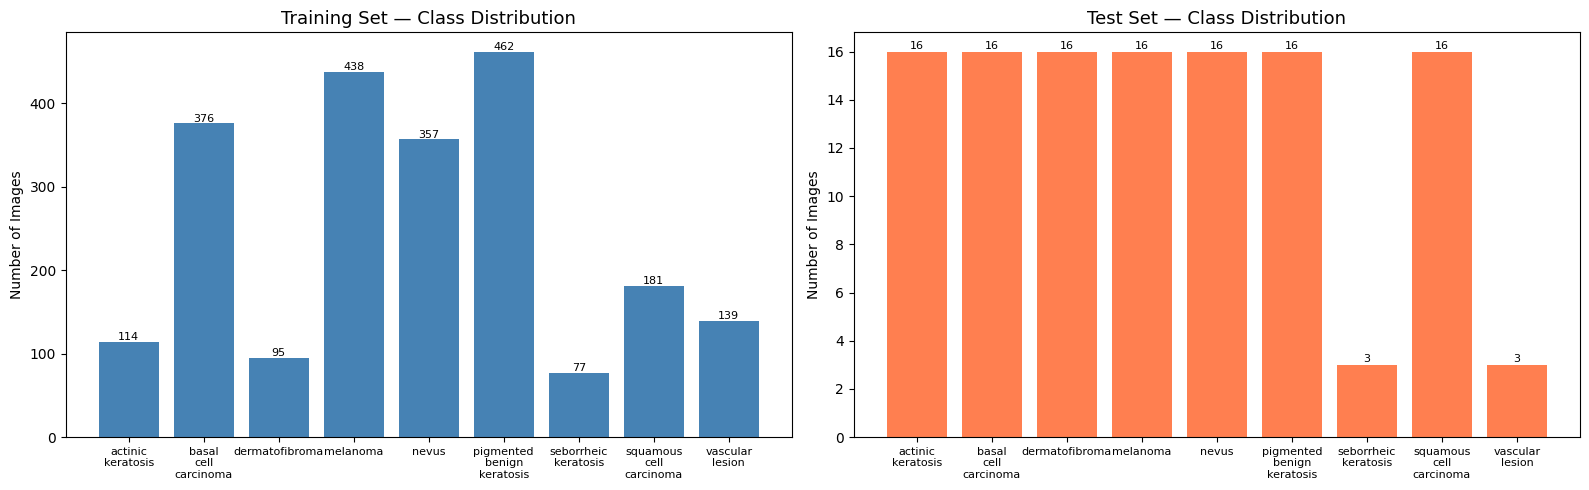


Class imbalance ratio (max/min train): 6.0


In [9]:
# Cell 3: Data Understanding — count images per class

train_counts = {}
test_counts  = {}

for class_name in os.listdir(TRAIN_DIR):
    class_path = os.path.join(TRAIN_DIR, class_name)
    if os.path.isdir(class_path):
        train_counts[class_name] = len(os.listdir(class_path))

for class_name in os.listdir(TEST_DIR):
    class_path = os.path.join(TEST_DIR, class_name)
    if os.path.isdir(class_path):
        test_counts[class_name] = len(os.listdir(class_path))

total_train = sum(train_counts.values())
total_test  = sum(test_counts.values())

print("=" * 55)
print(f"{'Class':<35} {'Train':>8} {'Test':>8}")
print("=" * 55)
for cls in sorted(train_counts.keys()):
    print(f"{cls:<35} {train_counts.get(cls,0):>8} {test_counts.get(cls,0):>8}")
print("=" * 55)
print(f"{'TOTAL':<35} {total_train:>8} {total_test:>8}")

# Plot class distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

classes = sorted(train_counts.keys())
short_names = [c.replace(' ', '\n') for c in classes]

axes[0].bar(short_names, [train_counts[c] for c in classes], color='steelblue')
axes[0].set_title('Training Set — Class Distribution', fontsize=13)
axes[0].set_ylabel('Number of Images')
axes[0].tick_params(axis='x', labelsize=8)
for i, v in enumerate([train_counts[c] for c in classes]):
    axes[0].text(i, v + 2, str(v), ha='center', fontsize=8)

axes[1].bar(short_names, [test_counts.get(c, 0) for c in classes], color='coral')
axes[1].set_title('Test Set — Class Distribution', fontsize=13)
axes[1].set_ylabel('Number of Images')
axes[1].tick_params(axis='x', labelsize=8)
for i, v in enumerate([test_counts.get(c, 0) for c in classes]):
    axes[1].text(i, v + 0.1, str(v), ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()
print("\nClass imbalance ratio (max/min train):",
      round(max(train_counts.values()) / min(train_counts.values()), 2))

Cell 4 — Visualize Sample Images

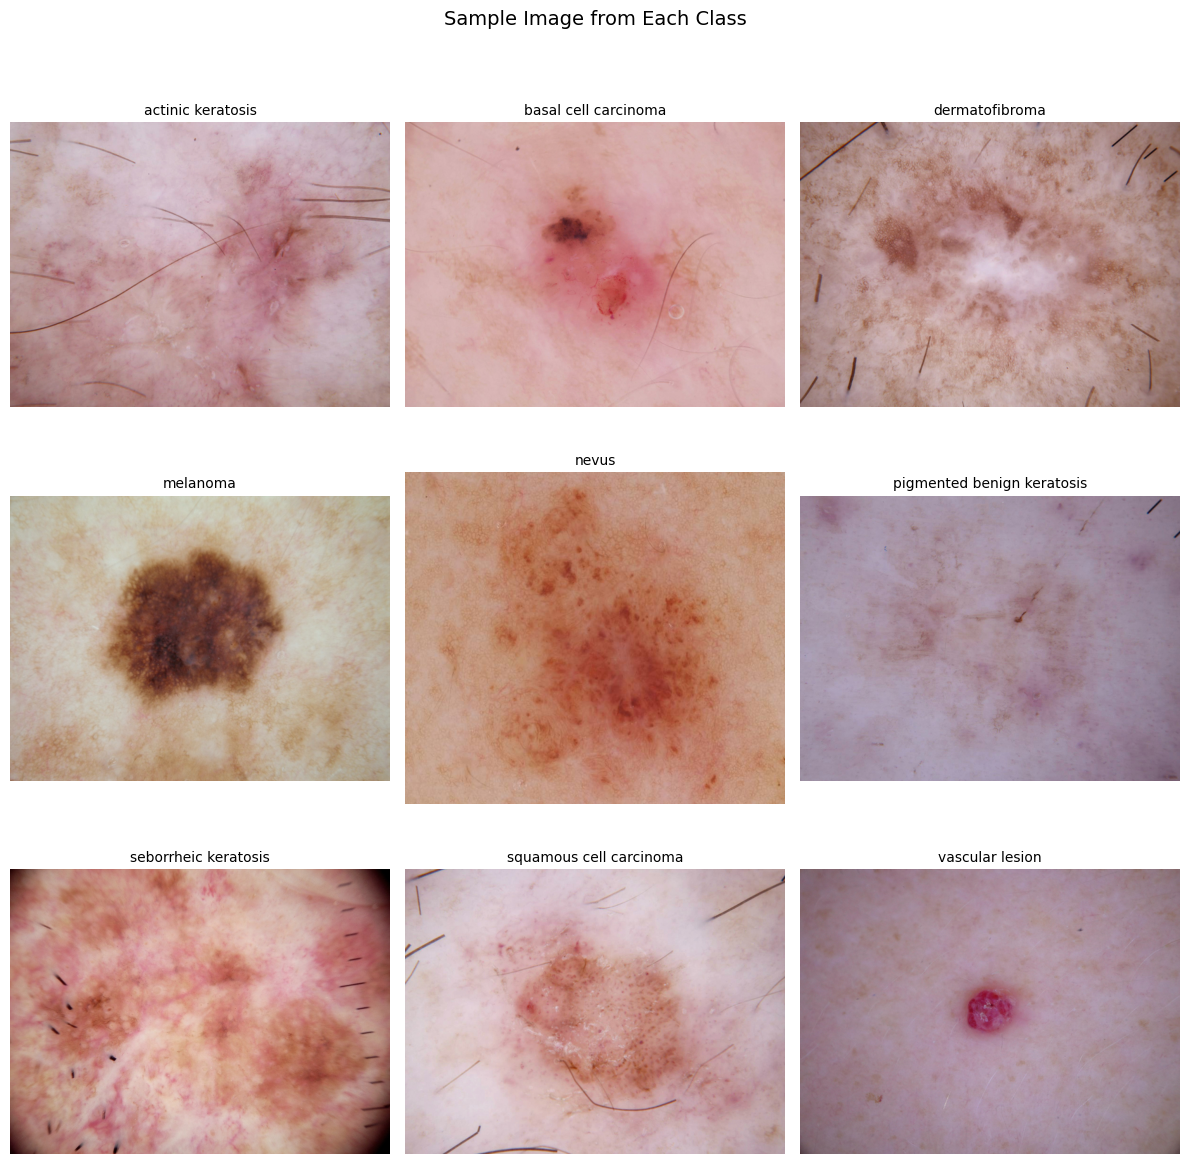

In [10]:
# Visualize sample images from each class (skips corrupt files)

from PIL import Image

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten()

for i, class_name in enumerate(sorted(train_counts.keys())):
    class_path = os.path.join(TRAIN_DIR, class_name)
    images = os.listdir(class_path)

    # Try images until we find a valid one
    img_loaded = False
    for img_file in images:
        img_path = os.path.join(class_path, img_file)
        try:
            img = Image.open(img_path).convert('RGB')
            axes[i].imshow(img)
            axes[i].set_title(class_name, fontsize=10)
            axes[i].set_xlabel(f"Size: {img.size}", fontsize=8)
            axes[i].axis('off')
            img_loaded = True
            break
        except Exception:
            continue  # skip corrupt file, try next

    if not img_loaded:
        axes[i].set_title(f"{class_name}\n(no valid image)", fontsize=10)
        axes[i].axis('off')

plt.suptitle('Sample Image from Each Class', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150)
plt.show()

## Train/Validation Split

An 80/20 train/validation split was chosen as it is the standard convention 
for moderately sized datasets in deep learning. Allocating 80% for training 
ensures the model has sufficient samples to learn across all 9 imbalanced 
classes, while the 20% validation set is large enough to reliably estimate 
generalisation performance without wasting training data.

Cell 5 — Data Augmentation & Generators

In [11]:
# Cell 5: Data Preprocessing and Augmentation

# Training generator WITH augmentation (as planned in proposal)
train_datagen = ImageDataGenerator(
    rescale=1./255,                  # normalize pixels to [0,1]
    horizontal_flip=True,            # random left-right mirror
    rotation_range=30,               # random rotation up to ±30°
    zoom_range=0.15,                 # random zoom ±15%
    brightness_range=[0.75, 1.25],   # random brightness shift
    validation_split=0.2             # 20% of train data used for validation
)

# Test/Validation generator — NO augmentation, only rescaling
test_datagen = ImageDataGenerator(rescale=1./255)

# Training set (80% of Train folder)
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=42
)

# Validation set (20% of Train folder)
val_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=42
)

# Test set (untouched Test folder)
test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False  # important: keep order for evaluation
)

print(f"\nTraining samples:   {train_generator.samples}")
print(f"Validation samples: {val_generator.samples}")
print(f"Test samples:       {test_generator.samples}")
print(f"Class indices: {train_generator.class_indices}")

Found 1795 images belonging to 9 classes.
Found 444 images belonging to 9 classes.
Found 118 images belonging to 9 classes.

Training samples:   1795
Validation samples: 444
Test samples:       118
Class indices: {'actinic keratosis': 0, 'basal cell carcinoma': 1, 'dermatofibroma': 2, 'melanoma': 3, 'nevus': 4, 'pigmented benign keratosis': 5, 'seborrheic keratosis': 6, 'squamous cell carcinoma': 7, 'vascular lesion': 8}


Cell 6 — Visualize Augmented Images

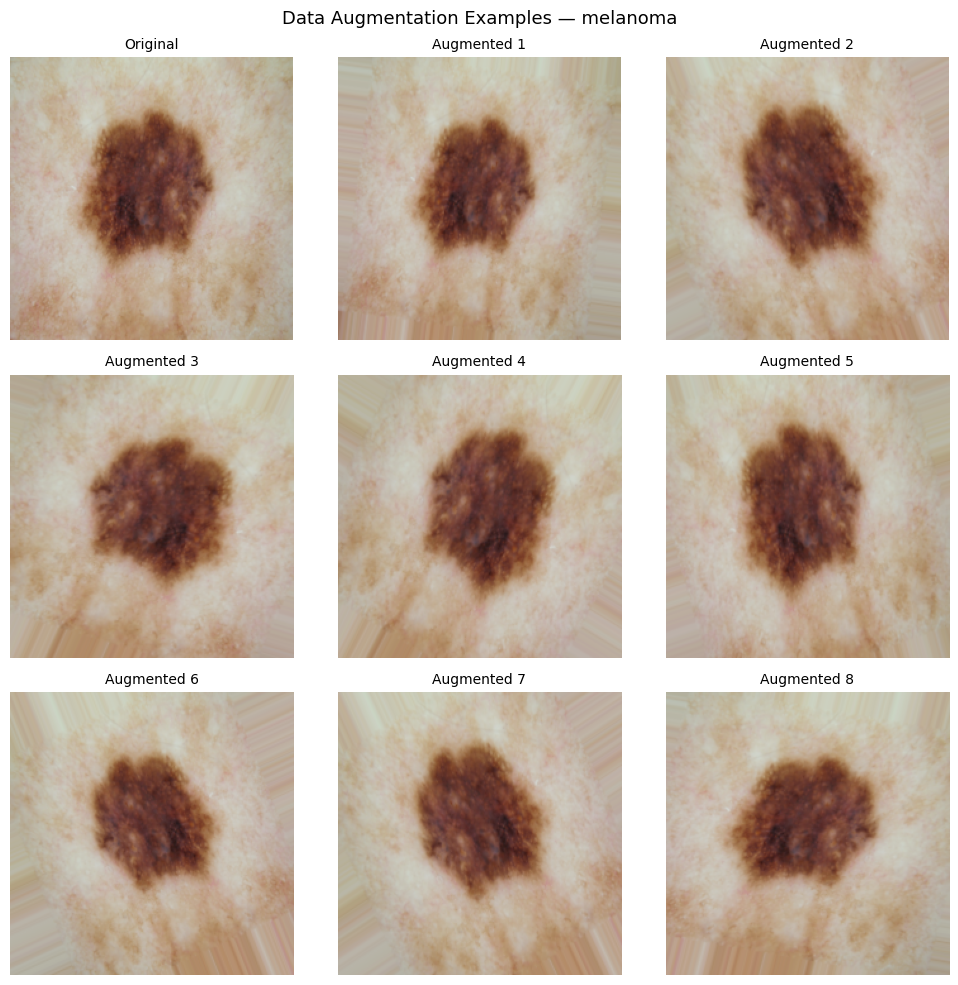

In [12]:
# Cell 6: Visualize augmented images (required by assignment)

from PIL import Image as PILImage

sample_class = 'melanoma'
sample_dir   = os.path.join(TRAIN_DIR, sample_class)

# Find a valid (non-corrupt) image
sample_file = None
for f in os.listdir(sample_dir):
    try:
        img = PILImage.open(os.path.join(sample_dir, f)).convert('RGB')
        sample_file = f
        break
    except:
        continue

# Load, resize, prepare
img = PILImage.open(os.path.join(sample_dir, sample_file)).convert('RGB')
img = img.resize(IMG_SIZE)
img_array = np.array(img)
img_array = img_array.reshape((1,) + img_array.shape)

# Augmentation generator WITHOUT brightness_range for visualization
aug_gen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    rotation_range=30,
    zoom_range=0.15
)

fig, axes = plt.subplots(3, 3, figsize=(10, 10))
axes = axes.flatten()

# Original
axes[0].imshow(img_array[0])
axes[0].set_title('Original', fontsize=10)
axes[0].axis('off')

# Augmented
aug_iter = aug_gen.flow(img_array, batch_size=1, seed=42)
for j in range(1, 9):
    aug_img = next(aug_iter)[0]
    axes[j].imshow(aug_img)
    axes[j].set_title(f'Augmented {j}', fontsize=10)
    axes[j].axis('off')

plt.suptitle(f'Data Augmentation Examples — {sample_class}', fontsize=13)
plt.tight_layout()
plt.savefig('augmentation_examples.png', dpi=150)
plt.show()

Cell 7 — Compute Class Weights

In [13]:
# Cell 7: Compute class weights to handle class imbalance

from sklearn.utils.class_weight import compute_class_weight

# Get all training labels
train_labels = train_generator.classes

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = dict(enumerate(class_weights_array))

print("Class weights (higher = model pays more attention to that class):")
for idx, cls in enumerate(train_generator.class_indices):
    print(f"  {cls:<35} → weight: {class_weights[idx]:.4f}")

Class weights (higher = model pays more attention to that class):
  actinic keratosis                   → weight: 2.1679
  basal cell carcinoma                → weight: 0.6626
  dermatofibroma                      → weight: 2.6243
  melanoma                            → weight: 0.5682
  nevus                               → weight: 0.6974
  pigmented benign keratosis          → weight: 0.5390
  seborrheic keratosis                → weight: 3.2168
  squamous cell carcinoma             → weight: 1.3755
  vascular lesion                     → weight: 1.7808


Cell 8 — Build Baseline CNN

In [14]:
# Cell 8: Part A — Baseline CNN Model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten,
                                     Dense, Dropout, BatchNormalization)

def build_baseline_model(input_shape=(224, 224, 3), num_classes=9):
    model = Sequential([

        # --- Convolutional Block 1 ---
        Conv2D(32, (3, 3), activation='relu', padding='same',
               input_shape=input_shape),
        MaxPooling2D((2, 2)),

        # --- Convolutional Block 2 ---
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),

        # --- Convolutional Block 3 ---
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),

        # --- Flatten ---
        Flatten(),

        # --- Fully Connected Layers ---
        Dense(256, activation='relu'),
        Dense(128, activation='relu'),
        Dense(64,  activation='relu'),

        # --- Output Layer ---
        Dense(num_classes, activation='softmax')
    ], name='Baseline_CNN')

    return model

baseline_model = build_baseline_model()

baseline_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

baseline_model.summary()

I0000 00:00:1778172833.685318      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778172833.691483      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 9)              │           585 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,825,353 (98.52 MB)

 Trainable params: 25,825,353 (98.52 MB)

 Non-trainable params: 0 (0.00 B)

Cell 9- Copy only clean images to working directory

In [15]:
# Cell 9b (Kaggle version): Copy only clean images to working directory

from PIL import Image as PILImage
import os, shutil

CLEAN_DIR   = '/kaggle/working/dataset_clean'
TRAIN_CLEAN = os.path.join(CLEAN_DIR, 'Train')
TEST_CLEAN  = os.path.join(CLEAN_DIR, 'Test')

def copy_clean_images(src_dir, dst_dir):
    copied = 0
    skipped = 0
    for class_name in os.listdir(src_dir):
        src_class = os.path.join(src_dir, class_name)
        dst_class = os.path.join(dst_dir, class_name)
        if not os.path.isdir(src_class):
            continue
        os.makedirs(dst_class, exist_ok=True)
        for file in os.listdir(src_class):
            src_file = os.path.join(src_class, file)
            try:
                with PILImage.open(src_file) as img:
                    img.load()
                    img.convert('RGB')
                shutil.copy2(src_file, dst_class)
                copied += 1
            except Exception:
                print(f"  Skipping corrupt: {file}")
                skipped += 1
    return copied, skipped

print("Copying clean Train images...")
c, s = copy_clean_images(TRAIN_DIR, TRAIN_CLEAN)
print(f"  Copied: {c}  |  Skipped (corrupt): {s}")

print("\nCopying clean Test images...")
c, s = copy_clean_images(TEST_DIR, TEST_CLEAN)
print(f"  Copied: {c}  |  Skipped (corrupt): {s}")

# Update paths to clean dataset
TRAIN_DIR = TRAIN_CLEAN
TEST_DIR  = TEST_CLEAN
print(f"\nPaths updated!")
print(f"  TRAIN_DIR = {TRAIN_DIR}")
print(f"  TEST_DIR  = {TEST_DIR}")

Copying clean Train images...
  Copied: 2239  |  Skipped (corrupt): 0

Copying clean Test images...
  Copied: 118  |  Skipped (corrupt): 0

Paths updated!
  TRAIN_DIR = /kaggle/working/dataset_clean/Train
  TEST_DIR  = /kaggle/working/dataset_clean/Test


Cell 10 — Train Baseline CNN

In [16]:
# Cell 10: Train Baseline CNN

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, min_lr=1e-6, verbose=1)
]

print("Training Baseline CNN...")
start_time = time.time()

baseline_history = baseline_model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

baseline_train_time = time.time() - start_time
print(f"\nBaseline training time: {baseline_train_time/60:.2f} minutes")

Training Baseline CNN...
Epoch 1/30


I0000 00:00:1778172889.175549     185 service.cc:152] XLA service 0x7c47b0011200 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778172889.175611     185 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778172889.175617     185 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778172889.724806     185 cuda_dnn.cc:529] Loaded cuDNN version 91002


 2/57 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.1250 - loss: 2.3356

I0000 00:00:1778172895.122130     185 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


27/57 ━━━━━━━━━━━━━━━━━━━━ 18s 601ms/step - accuracy: 0.1003 - loss: 2.2049

2026-05-07 16:55:11.795058: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-07 16:55:11.937497: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


57/57 ━━━━━━━━━━━━━━━━━━━━ 57s 864ms/step - accuracy: 0.1070 - loss: 2.1966 - val_accuracy: 0.2117 - val_loss: 2.2013 - learning_rate: 0.0010
Epoch 2/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 44s 776ms/step - accuracy: 0.1720 - loss: 2.0867 - val_accuracy: 0.1959 - val_loss: 1.9547 - learning_rate: 0.0010
Epoch 3/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 43s 762ms/step - accuracy: 0.2654 - loss: 1.9155 - val_accuracy: 0.2658 - val_loss: 2.1918 - learning_rate: 0.0010
Epoch 4/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 43s 759ms/step - accuracy: 0.3385 - loss: 1.6459 - val_accuracy: 0.3423 - val_loss: 2.0231 - learning_rate: 0.0010
Epoch 5/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 593ms/step - accuracy: 0.3176 - loss: 1.5638
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
57/57 ━━━━━━━━━━━━━━━━━━━━ 43s 760ms/step - accuracy: 0.3176 - loss: 1.5636 - val_accuracy: 0.4032 - val_loss: 2.0746 - learning_rate: 0.0010
Epoch 6/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 43s 760ms/step - accuracy: 0.4317 - loss: 1.5072 - val_ac

Cell 11 — Plot Baseline Training Curves

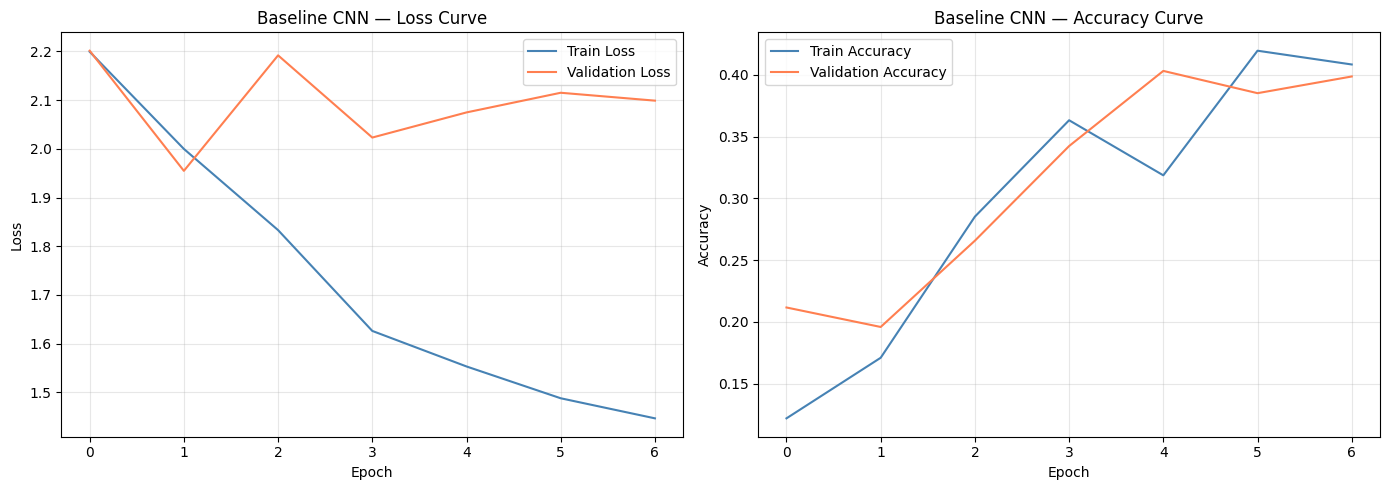

In [17]:
# Cell 11: Plot training vs validation loss and accuracy

def plot_history(history, model_name='Baseline CNN'):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Loss
    axes[0].plot(history.history['loss'],     label='Train Loss',      color='steelblue')
    axes[0].plot(history.history['val_loss'], label='Validation Loss', color='coral')
    axes[0].set_title(f'{model_name} — Loss Curve')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Accuracy
    axes[1].plot(history.history['accuracy'],     label='Train Accuracy',      color='steelblue')
    axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', color='coral')
    axes[1].set_title(f'{model_name} — Accuracy Curve')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{model_name.replace(" ", "_")}_curves.png', dpi=150)
    plt.show()

plot_history(baseline_history, 'Baseline CNN')

Cell 12 — Evaluate Baseline CNN

4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step

Classification Report — Baseline CNN
                            precision    recall  f1-score   support

         actinic keratosis       0.00      0.00      0.00        16
      basal cell carcinoma       0.00      0.00      0.00        16
            dermatofibroma       0.00      0.00      0.00        16
                  melanoma       0.00      0.00      0.00        16
                     nevus       0.35      0.50      0.41        16
pigmented benign keratosis       0.00      0.00      0.00        16
      seborrheic keratosis       0.00      0.00      0.00         3
   squamous cell carcinoma       0.00      0.00      0.00        16
           vascular lesion       0.04      1.00      0.07         3

                  accuracy                           0.09       118
                 macro avg       0.04      0.17      0.05       118
              weighted avg       0.05      0.09      0.06       118



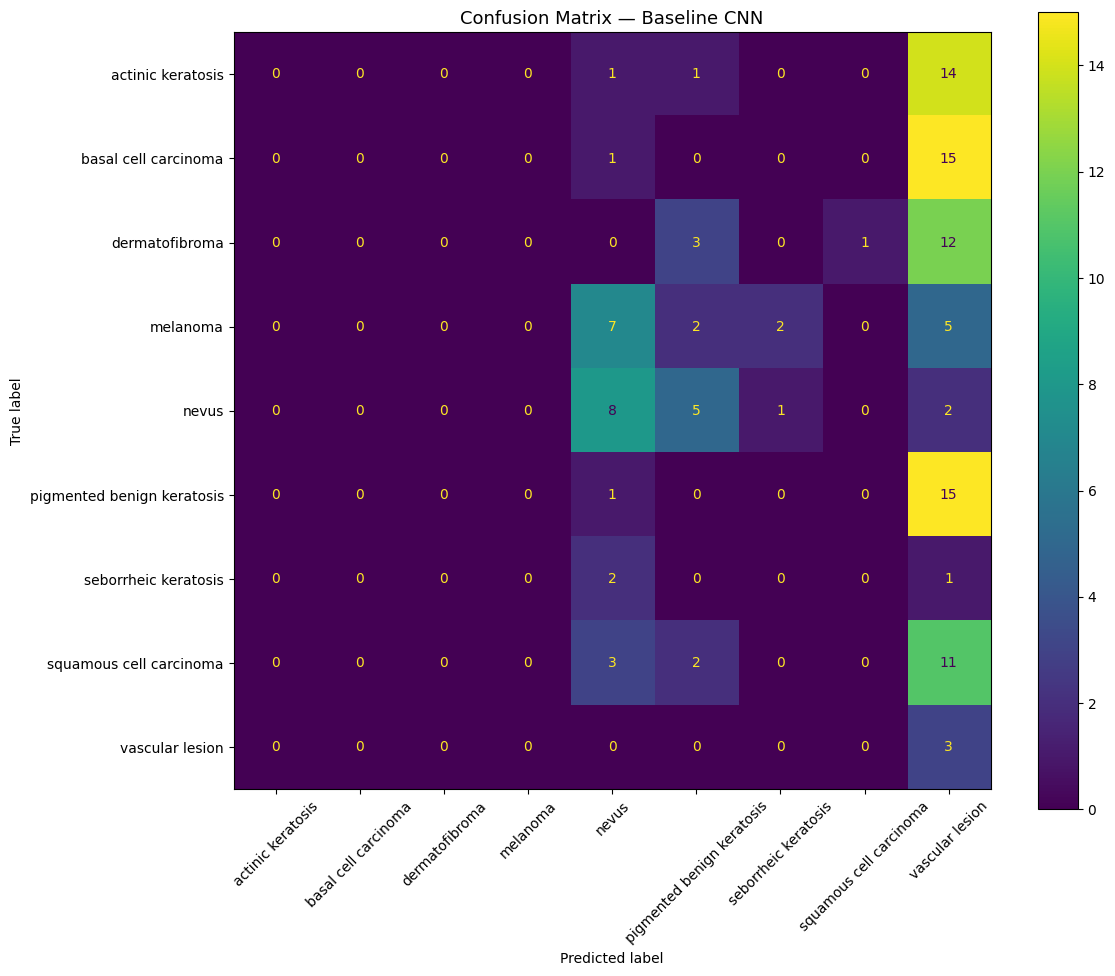

In [18]:
# Cell 12: Evaluate Baseline CNN on test set

# Reset test generator before evaluation
test_generator.reset()

# Get predictions
test_preds  = baseline_model.predict(test_generator, verbose=1)
pred_labels = np.argmax(test_preds, axis=1)
true_labels = test_generator.classes
class_names = list(test_generator.class_indices.keys())

# Classification report
print("\nClassification Report — Baseline CNN")
print("=" * 60)
print(classification_report(true_labels, pred_labels,
                             target_names=class_names))

# Confusion matrix
fig, ax = plt.subplots(figsize=(12, 10))
cm = confusion_matrix(true_labels, pred_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=class_names)
disp.plot(ax=ax, xticks_rotation=45, colorbar=True)
ax.set_title('Confusion Matrix — Baseline CNN', fontsize=13)
plt.tight_layout()
plt.savefig('baseline_confusion_matrix.png', dpi=150)
plt.show()

Cell 13 — Inference on Sample Images

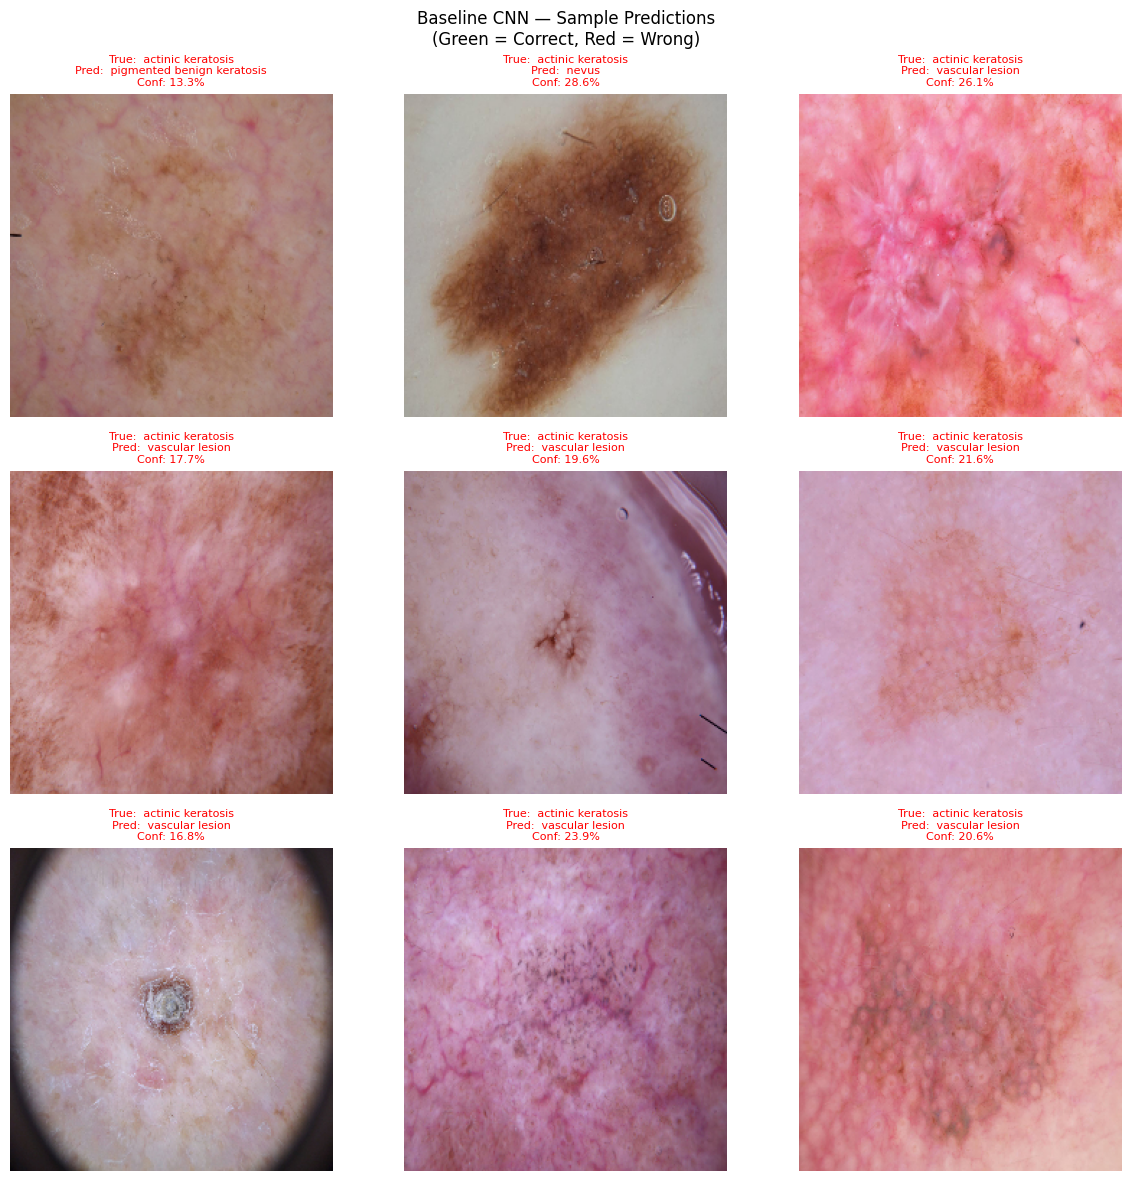

In [19]:
# Cell 13: Run inference on sample test images and visualize predictions

test_generator.reset()
images, labels = next(test_generator)

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten()

for i in range(9):
    img        = images[i]
    true_idx   = np.argmax(labels[i])
    pred_probs = baseline_model.predict(img.reshape(1, *IMG_SIZE, 3), verbose=0)
    pred_idx   = np.argmax(pred_probs)
    confidence = np.max(pred_probs) * 100

    axes[i].imshow(img)
    color = 'green' if pred_idx == true_idx else 'red'
    axes[i].set_title(
        f"True:  {class_names[true_idx]}\n"
        f"Pred:  {class_names[pred_idx]}\n"
        f"Conf: {confidence:.1f}%",
        fontsize=8, color=color
    )
    axes[i].axis('off')

plt.suptitle('Baseline CNN — Sample Predictions\n(Green = Correct, Red = Wrong)',
             fontsize=12)
plt.tight_layout()
plt.savefig('baseline_sample_predictions.png', dpi=150)
plt.show()

**Cell 14 — Build Deeper CNN**

In [20]:
# Cell 14: Part A — Deeper CNN with Regularization
# At least double the layers compared to baseline (assignment requirement)

from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten,
                                     Dense, Dropout, BatchNormalization)

def build_deeper_model(input_shape=(224, 224, 3), num_classes=9):
    model = Sequential([

        # --- Block 1 ---
        Conv2D(32, (3, 3), activation='relu', padding='same',
               input_shape=input_shape),
        BatchNormalization(),
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        # --- Block 2 ---
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        # --- Block 3 ---
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        # --- Block 4 ---
        Conv2D(256, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(256, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        # --- Block 5 ---
        Conv2D(512, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(512, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        # --- Flatten ---
        Flatten(),

        # --- Fully Connected Layers ---
        Dense(512, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),

        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),

        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),

        # --- Output Layer ---
        Dense(num_classes, activation='softmax')
    ], name='Deeper_CNN')

    return model

deeper_model = build_deeper_model()

deeper_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

deeper_model.summary()

Model: "Deeper_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 28, 28, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 17,734,697 (67.65 MB)

 Trainable params: 17,728,937 (67.63 MB)

 Non-trainable params: 5,760 (22.50 KB)

Cell 15 — Train Deeper CNN

In [21]:
# Cell 15 (Fixed): Train Deeper CNN with better settings

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks_deeper = [
    EarlyStopping(monitor='val_loss', patience=8,        # more patience
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3,    # more aggressive LR reduction
                      patience=4, min_lr=1e-7, verbose=1)
]

# Recompile with lower learning rate
deeper_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),  # lower LR
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

train_generator.reset()
val_generator.reset()

print("Training Deeper CNN (fixed LR)...")
start_time = time.time()

deeper_history = deeper_model.fit(
    train_generator,
    epochs=40,
    validation_data=val_generator,
    class_weight=class_weights,
    callbacks=callbacks_deeper,
    verbose=1
)

deeper_train_time = time.time() - start_time
print(f"\nDeeper CNN training time: {deeper_train_time/60:.2f} minutes")
print(f"Baseline training time:   {baseline_train_time/60:.2f} minutes")

Training Deeper CNN (fixed LR)...
Epoch 1/40


2026-05-07 17:00:42.278052: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-07 17:00:42.434970: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-07 17:00:46.100092: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-07 17:00:46.390280: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-07 17:00:49.033418: E external/local_xla/xla/service

43/57 ━━━━━━━━━━━━━━━━━━━━ 8s 607ms/step - accuracy: 0.1376 - loss: 3.0315

2026-05-07 17:01:33.720845: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-07 17:01:33.867687: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-07 17:01:34.555228: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-07 17:01:34.843050: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


57/57 ━━━━━━━━━━━━━━━━━━━━ 113s 1s/step - accuracy: 0.1405 - loss: 3.0080 - val_accuracy: 0.0338 - val_loss: 2.2966 - learning_rate: 1.0000e-04
Epoch 2/40
57/57 ━━━━━━━━━━━━━━━━━━━━ 45s 782ms/step - accuracy: 0.1731 - loss: 2.6755 - val_accuracy: 0.0428 - val_loss: 2.5528 - learning_rate: 1.0000e-04
Epoch 3/40
57/57 ━━━━━━━━━━━━━━━━━━━━ 47s 816ms/step - accuracy: 0.2154 - loss: 2.5366 - val_accuracy: 0.0833 - val_loss: 2.4784 - learning_rate: 1.0000e-04
Epoch 4/40
57/57 ━━━━━━━━━━━━━━━━━━━━ 46s 801ms/step - accuracy: 0.2292 - loss: 2.3960 - val_accuracy: 0.0450 - val_loss: 2.4333 - learning_rate: 1.0000e-04
Epoch 5/40
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 632ms/step - accuracy: 0.2422 - loss: 2.2249
Epoch 5: ReduceLROnPlateau reducing learning rate to 2.9999999242136255e-05.
57/57 ━━━━━━━━━━━━━━━━━━━━ 46s 802ms/step - accuracy: 0.2423 - loss: 2.2268 - val_accuracy: 0.1104 - val_loss: 2.9367 - learning_rate: 1.0000e-04
Epoch 6/40
57/57 ━━━━━━━━━━━━━━━━━━━━ 46s 812ms/step - accuracy: 0.2594 - lo

Cell 16 — Plot & Compare Training Curves

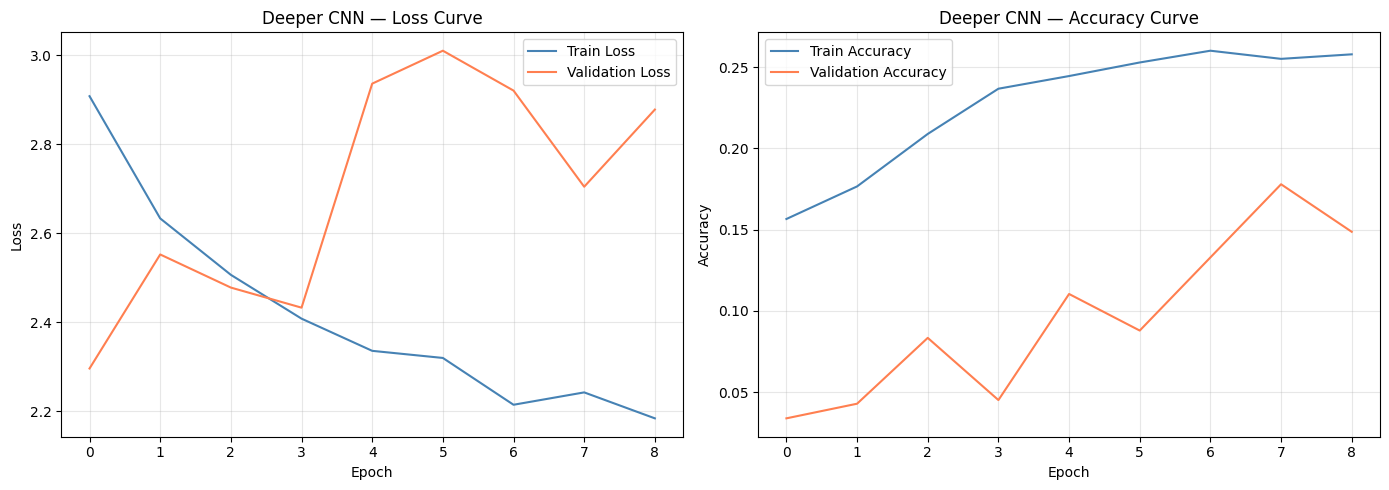

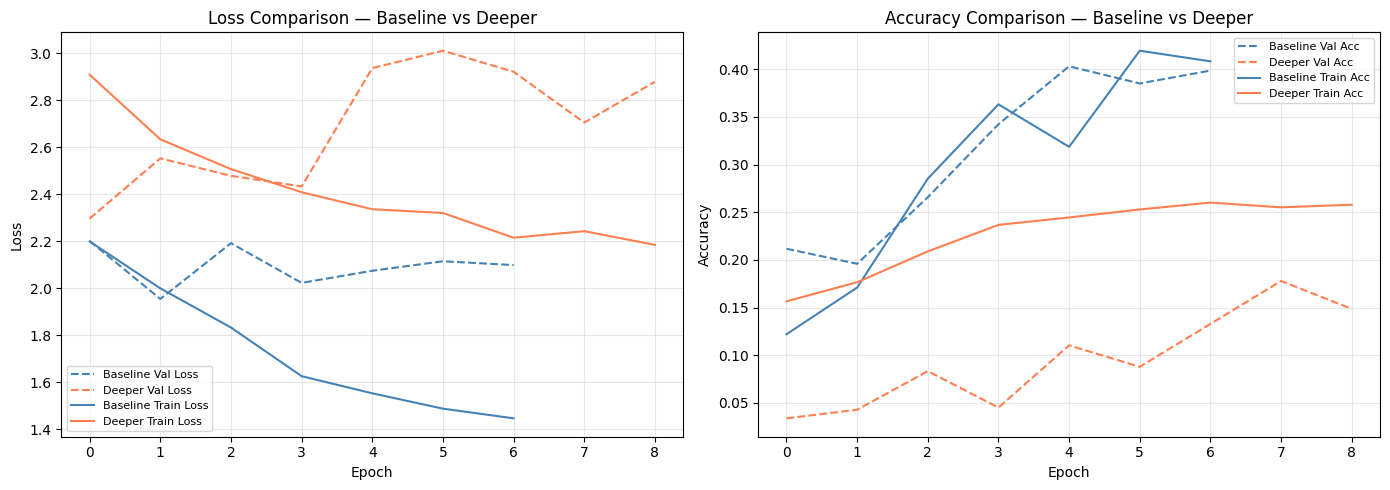

In [22]:
# Cell 16: Plot deeper model curves and compare with baseline

plot_history(deeper_history, 'Deeper CNN')

# Side by side comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss comparison
axes[0].plot(baseline_history.history['val_loss'],
             label='Baseline Val Loss', color='steelblue', linestyle='--')
axes[0].plot(deeper_history.history['val_loss'],
             label='Deeper Val Loss',   color='coral',     linestyle='--')
axes[0].plot(baseline_history.history['loss'],
             label='Baseline Train Loss', color='steelblue')
axes[0].plot(deeper_history.history['loss'],
             label='Deeper Train Loss',   color='coral')
axes[0].set_title('Loss Comparison — Baseline vs Deeper')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# Accuracy comparison
axes[1].plot(baseline_history.history['val_accuracy'],
             label='Baseline Val Acc', color='steelblue', linestyle='--')
axes[1].plot(deeper_history.history['val_accuracy'],
             label='Deeper Val Acc',   color='coral',     linestyle='--')
axes[1].plot(baseline_history.history['accuracy'],
             label='Baseline Train Acc', color='steelblue')
axes[1].plot(deeper_history.history['accuracy'],
             label='Deeper Train Acc',   color='coral')
axes[1].set_title('Accuracy Comparison — Baseline vs Deeper')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('baseline_vs_deeper_comparison.png', dpi=150)
plt.show()

Cell 17 — Evaluate Deeper CNN

In [23]:
# Cell 17a: Classification Report — Deeper CNN

test_generator.reset()

deeper_preds       = deeper_model.predict(test_generator, verbose=1)
deeper_pred_labels = np.argmax(deeper_preds, axis=1)
true_labels        = test_generator.classes
class_names        = list(test_generator.class_indices.keys())

print("\nClassification Report — Deeper CNN")
print("=" * 60)
print(classification_report(true_labels, deeper_pred_labels,
                             target_names=class_names))

4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 3s/step  

Classification Report — Deeper CNN
                            precision    recall  f1-score   support

         actinic keratosis       0.00      0.00      0.00        16
      basal cell carcinoma       0.00      0.00      0.00        16
            dermatofibroma       0.00      0.00      0.00        16
                  melanoma       0.00      0.00      0.00        16
                     nevus       0.00      0.00      0.00        16
pigmented benign keratosis       0.00      0.00      0.00        16
      seborrheic keratosis       0.03      1.00      0.05         3
   squamous cell carcinoma       0.00      0.00      0.00        16
           vascular lesion       0.00      0.00      0.00         3

                  accuracy                           0.03       118
                 macro avg       0.00      0.11      0.01       118
              weighted avg       0.00      0.03      0.00       118



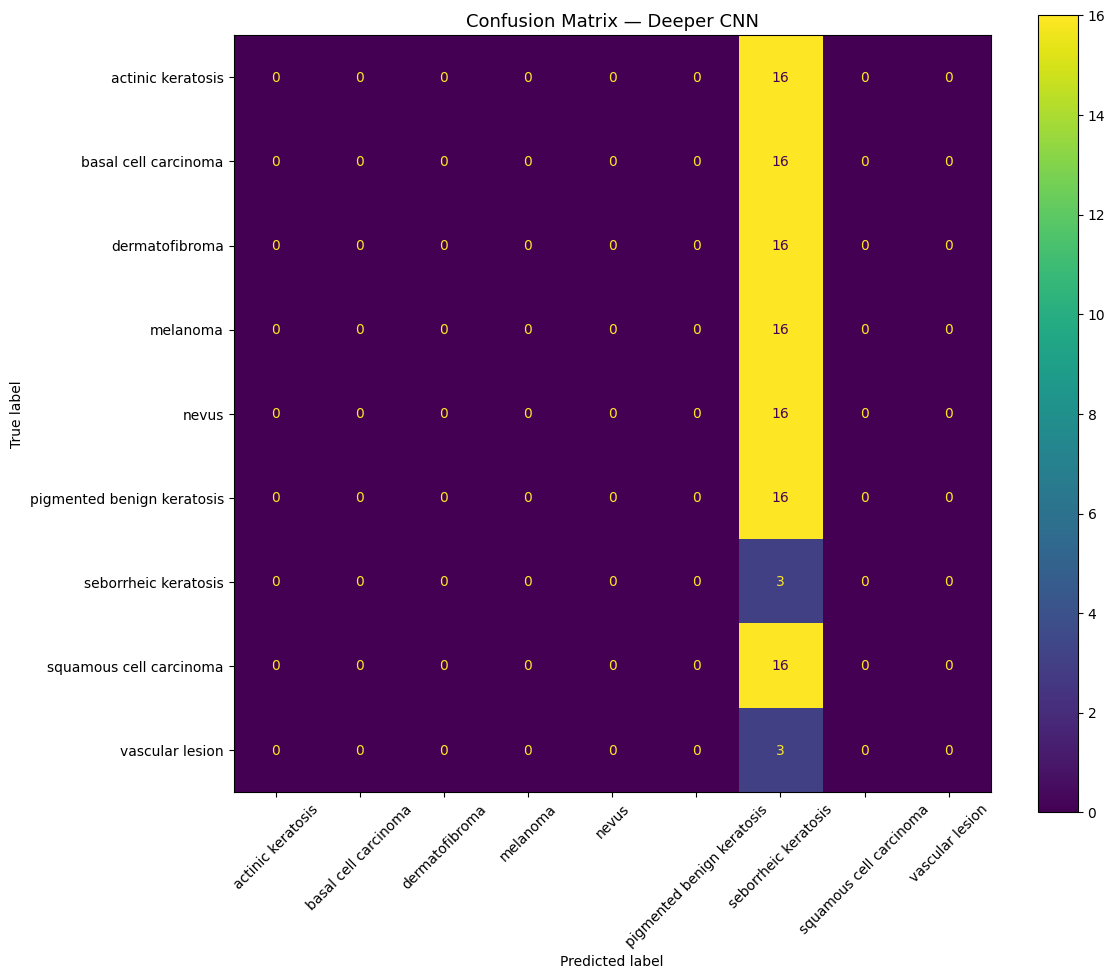

In [24]:
# Cell 17b: Confusion Matrix — Deeper CNN

fig, ax = plt.subplots(figsize=(12, 10))
cm   = confusion_matrix(true_labels, deeper_pred_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=class_names)
disp.plot(ax=ax, xticks_rotation=45, colorbar=True)
ax.set_title('Confusion Matrix — Deeper CNN', fontsize=13)
plt.tight_layout()
plt.savefig('deeper_confusion_matrix.png', dpi=150)
plt.show()

In [25]:
# Cell 17c: Performance Summary — Baseline vs Deeper

print("=" * 50)
print("PERFORMANCE SUMMARY")
print("=" * 50)
baseline_acc = max(baseline_history.history['val_accuracy'])
deeper_acc   = max(deeper_history.history['val_accuracy'])
print(f"Baseline CNN — Best Val Accuracy: {baseline_acc*100:.2f}%")
print(f"Deeper CNN   — Best Val Accuracy: {deeper_acc*100:.2f}%")
print(f"Baseline training time: {baseline_train_time/60:.2f} min")
print(f"Deeper   training time: {deeper_train_time/60:.2f} min")

PERFORMANCE SUMMARY
Baseline CNN — Best Val Accuracy: 40.32%
Deeper CNN   — Best Val Accuracy: 17.79%
Baseline training time: 5.32 min
Deeper   training time: 8.05 min


Cell 18 — SGD Optimizer Experiment

In [26]:
# Cell 18: Experimentation — Train Deeper Model with SGD optimizer

deeper_model_sgd = build_deeper_model()

deeper_model_sgd.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_sgd = [
    EarlyStopping(monitor='val_loss', patience=5,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, min_lr=1e-6, verbose=1)
]

train_generator.reset()
val_generator.reset()

print("Training Deeper CNN with SGD...")
start_time = time.time()

sgd_history = deeper_model_sgd.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    class_weight=class_weights,
    callbacks=callbacks_sgd,
    verbose=1
)

sgd_train_time = time.time() - start_time
print(f"\nSGD training time: {sgd_train_time/60:.2f} minutes")

Training Deeper CNN with SGD...
Epoch 1/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.1061 - loss: 2.9822 - val_accuracy: 0.1577 - val_loss: 4650.6123 - learning_rate: 0.0100
Epoch 2/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 47s 815ms/step - accuracy: 0.1511 - loss: 2.4822 - val_accuracy: 0.0338 - val_loss: 58.6515 - learning_rate: 0.0100
Epoch 3/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 46s 807ms/step - accuracy: 0.1321 - loss: 2.3784 - val_accuracy: 0.0923 - val_loss: 5.8750 - learning_rate: 0.0100
Epoch 4/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 45s 794ms/step - accuracy: 0.1276 - loss: 2.2988 - val_accuracy: 0.1577 - val_loss: 3.1168 - learning_rate: 0.0100
Epoch 5/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 46s 809ms/step - accuracy: 0.1411 - loss: 2.2713 - val_accuracy: 0.2095 - val_loss: 2.7867 - learning_rate: 0.0100
Epoch 6/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 45s 793ms/step - accuracy: 0.1424 - loss: 2.2938 - val_accuracy: 0.1396 - val_loss: 2.4692 - learning_rate: 0.0100
Epoch 7/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 46s 803ms/s

Cell 19 — Compare SGD vs Adam

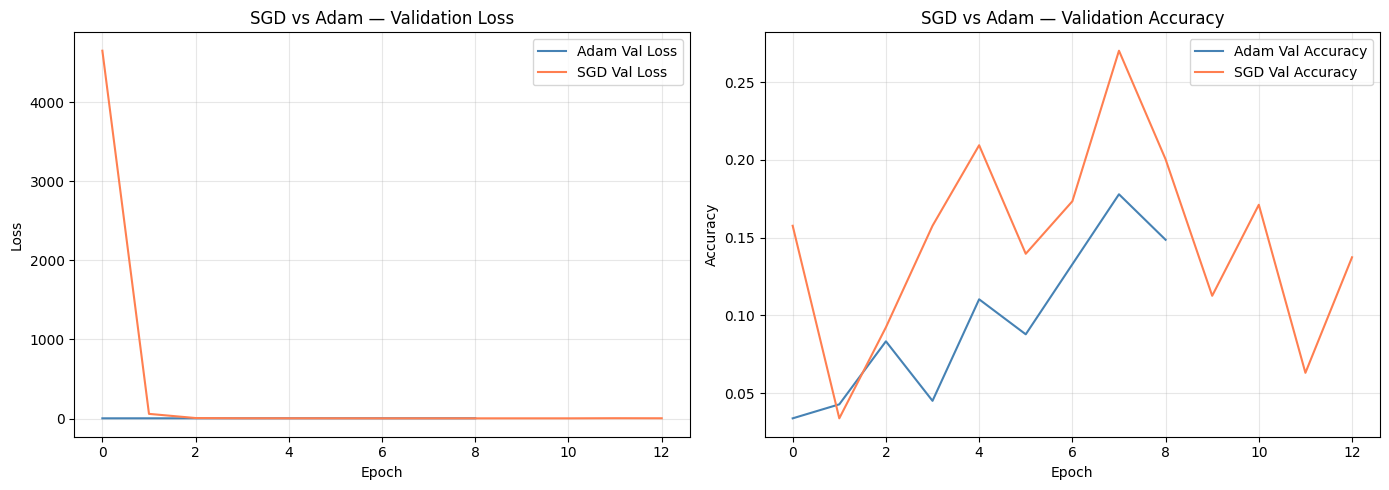

OPTIMIZER COMPARISON
Adam — Best Val Accuracy: 17.79%
SGD  — Best Val Accuracy: 27.03%
Adam — Training time: 8.05 min
SGD  — Training time: 10.51 min


In [27]:
# Cell 19: Compare SGD vs Adam — Plots and Report

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Val Loss
axes[0].plot(deeper_history.history['val_loss'],
             label='Adam Val Loss', color='steelblue')
axes[0].plot(sgd_history.history['val_loss'],
             label='SGD Val Loss',  color='coral')
axes[0].set_title('SGD vs Adam — Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Val Accuracy
axes[1].plot(deeper_history.history['val_accuracy'],
             label='Adam Val Accuracy', color='steelblue')
axes[1].plot(sgd_history.history['val_accuracy'],
             label='SGD Val Accuracy',  color='coral')
axes[1].set_title('SGD vs Adam — Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('sgd_vs_adam_comparison.png', dpi=150)
plt.show()

# Summary
adam_best = max(deeper_history.history['val_accuracy'])
sgd_best  = max(sgd_history.history['val_accuracy'])

print("=" * 45)
print("OPTIMIZER COMPARISON")
print("=" * 45)
print(f"Adam — Best Val Accuracy: {adam_best*100:.2f}%")
print(f"SGD  — Best Val Accuracy: {sgd_best*100:.2f}%")
print(f"Adam — Training time: {deeper_train_time/60:.2f} min")
print(f"SGD  — Training time: {sgd_train_time/60:.2f} min")

Cell 19a - SGD Model — Full Classification Report & Confusion Matrix

3/4 ━━━━━━━━━━━━━━━━━━━━ 0s 540ms/stepWARNING:tensorflow:5 out of the last 17 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x7c47d428a160> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step  
SGD Model - Classification Report
                            precision    recall  f1-score   support

         actinic keratosis       1.00      0.06      0.12        16
      basal cell carcinoma    

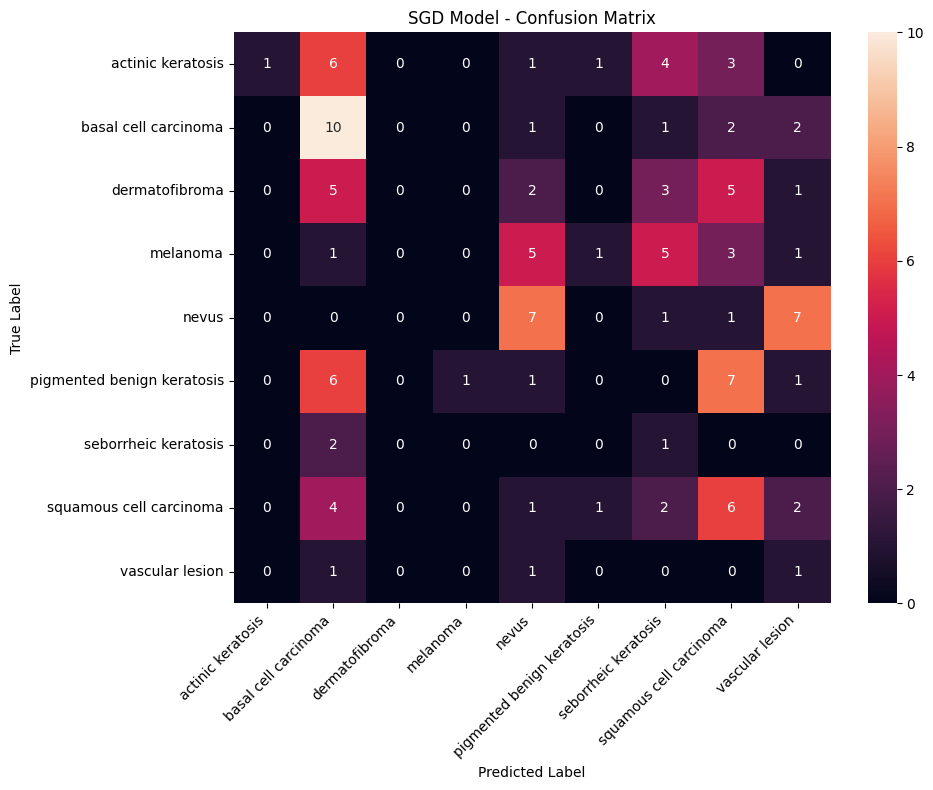

In [28]:
# SGD Model - Full Evaluation
import seaborn as sns

test_generator.reset()
y_pred_sgd = deeper_model_sgd.predict(test_generator, verbose=1)
y_pred_classes_sgd = np.argmax(y_pred_sgd, axis=1)
y_true_sgd = test_generator.classes
class_names = list(test_generator.class_indices.keys())

print("SGD Model - Classification Report")
print(classification_report(y_true_sgd, y_pred_classes_sgd, target_names=class_names))

cm_sgd = confusion_matrix(y_true_sgd, y_pred_classes_sgd)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_sgd, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.title("SGD Model - Confusion Matrix")
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Cell 20 — Ablation Study (Remove Dropout)

In [29]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

def build_ablation_model(input_shape=(224, 224, 3), num_classes=9):
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        BatchNormalization(),
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),

        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),

        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),

        Conv2D(256, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(256, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),

        Conv2D(512, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(512, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),

        Flatten(),
        Dense(512, activation='relu'),
        BatchNormalization(),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dense(num_classes, activation='softmax')
    ], name='Ablation_No_Dropout')
    return model

ablation_model = build_ablation_model()
ablation_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_ablation = [
    EarlyStopping(monitor='val_loss', patience=5,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, min_lr=1e-6, verbose=1)
]

train_generator.reset()
val_generator.reset()

print("Training Ablation Model (No Dropout)...")
start_time = time.time()

ablation_history = ablation_model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    class_weight=class_weights,
    callbacks=callbacks_ablation,
    verbose=1
)

ablation_train_time = time.time() - start_time
print(f"\nAblation training time: {ablation_train_time/60:.2f} minutes")

Training Ablation Model (No Dropout)...
Epoch 1/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.2493 - loss: 2.2865 - val_accuracy: 0.1306 - val_loss: 6.1450 - learning_rate: 0.0010
Epoch 2/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 50s 867ms/step - accuracy: 0.2468 - loss: 2.1935 - val_accuracy: 0.1374 - val_loss: 2.5550 - learning_rate: 0.0010
Epoch 3/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 48s 833ms/step - accuracy: 0.3291 - loss: 1.8213 - val_accuracy: 0.0811 - val_loss: 2.5254 - learning_rate: 0.0010
Epoch 4/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 46s 815ms/step - accuracy: 0.3477 - loss: 1.7886 - val_accuracy: 0.1667 - val_loss: 2.6920 - learning_rate: 0.0010
Epoch 5/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 44s 776ms/step - accuracy: 0.3939 - loss: 1.5794 - val_accuracy: 0.0450 - val_loss: 3.0054 - learning_rate: 0.0010
Epoch 6/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 44s 775ms/step - accuracy: 0.3782 - loss: 1.6116 - val_accuracy: 0.1689 - val_loss: 2.4114 - learning_rate: 0.0010
Epoch 7/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 45s 786

Cell 21 — Ablation Results

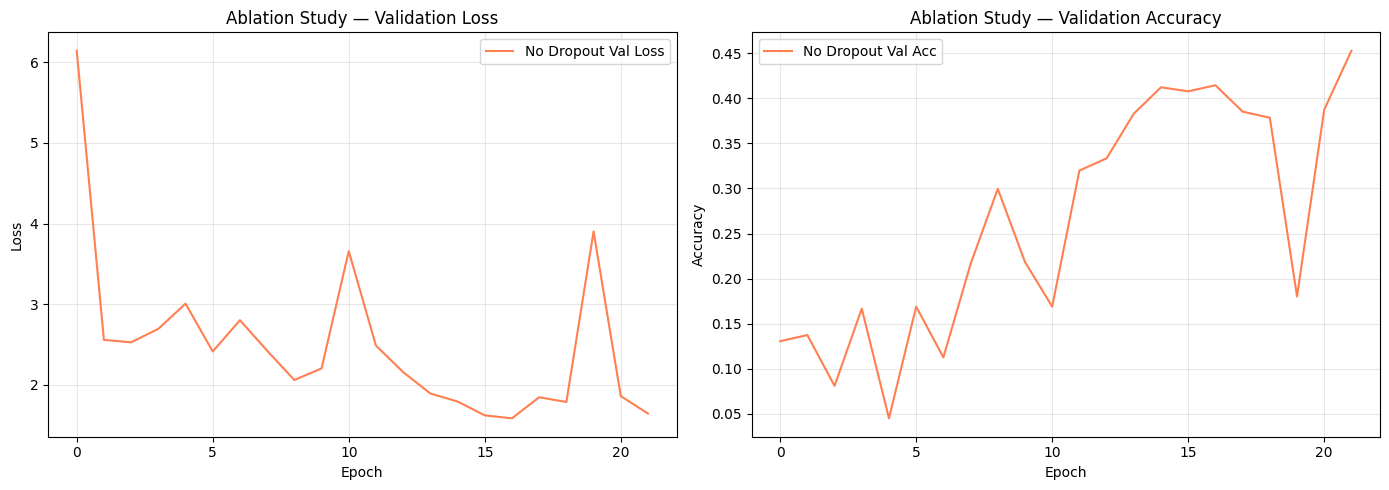

ABLATION STUDY RESULTS
Without Dropout — Best Val Accuracy: 45.27%
Ablation training time: 17.15 min


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(ablation_history.history['val_loss'], color='coral', label='No Dropout Val Loss')
axes[0].set_title('Ablation Study — Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(ablation_history.history['val_accuracy'], color='coral', label='No Dropout Val Acc')
axes[1].set_title('Ablation Study — Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('ablation_study.png', dpi=150)
plt.show()

ablation_best = max(ablation_history.history['val_accuracy'])
print("=" * 45)
print("ABLATION STUDY RESULTS")
print("=" * 45)
print(f"Without Dropout — Best Val Accuracy: {ablation_best*100:.2f}%")
print(f"Ablation training time: {ablation_train_time/60:.2f} min")

Cell 22 - Ablation Study — Side-by-Side Comparison

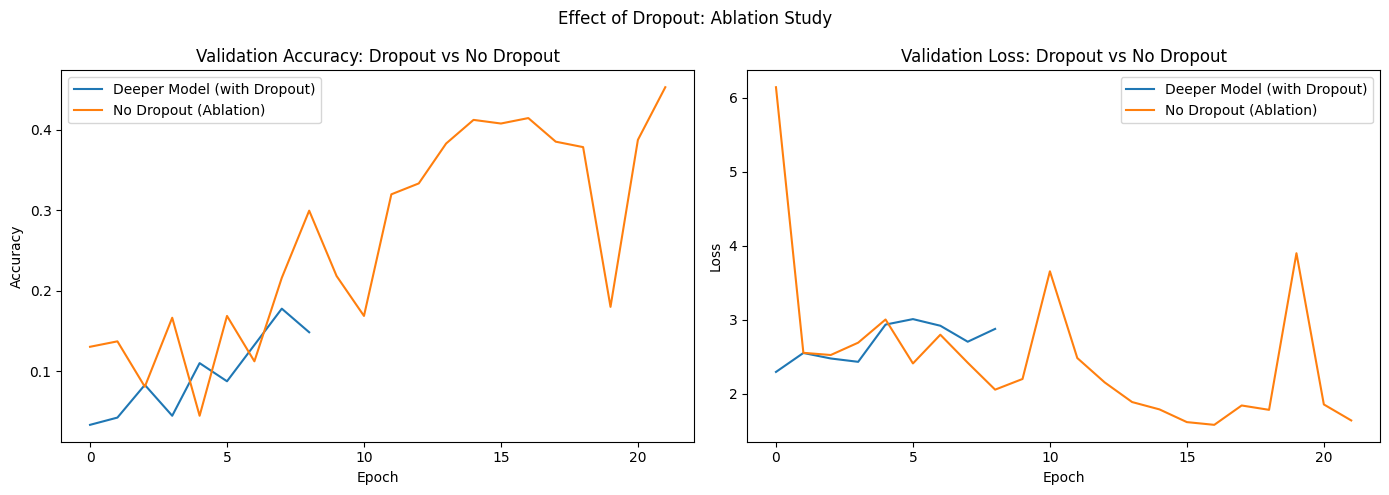

In [33]:
# Ablation Study - Side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(deeper_history.history['val_accuracy'], label='Deeper Model (with Dropout)')
axes[0].plot(ablation_history.history['val_accuracy'], label='No Dropout (Ablation)')
axes[0].set_title('Validation Accuracy: Dropout vs No Dropout')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(deeper_history.history['val_loss'], label='Deeper Model (with Dropout)')
axes[1].plot(ablation_history.history['val_loss'], label='No Dropout (Ablation)')
axes[1].set_title('Validation Loss: Dropout vs No Dropout')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.suptitle('Effect of Dropout: Ablation Study')
plt.tight_layout()
plt.show()

**Part B — Transfer Learning**

Cell 23 — Load Pre-trained ResNet50 & Build Transfer Learning Model

In [34]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.trainable = False

inputs  = tf.keras.Input(shape=(224, 224, 3))
x       = base_model(inputs, training=False)
x       = GlobalAveragePooling2D()(x)
x       = BatchNormalization()(x)
x       = Dense(256, activation='relu')(x)
x       = Dropout(0.5)(x)
x       = Dense(128, activation='relu')(x)
x       = Dropout(0.3)(x)
outputs = Dense(9, activation='softmax')(x)

transfer_model = Model(inputs, outputs, name='ResNet50_Transfer')
transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f"ResNet50 total layers: {len(base_model.layers)}")
print(f"Frozen layers: {sum(1 for l in base_model.layers if not l.trainable)}")
transfer_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
ResNet50 total layers: 175
Frozen layers: 175


Model: "ResNet50_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_39          │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,154,505 (92.14 MB)

 Trainable params: 562,697 (2.15 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

Cell 24 — Feature Extraction Training

In [35]:
# ============================
# CALLBACKS FOR TRANSFER LEARNING (ResNet50 Phase 1)
# ============================

callbacks_transfer = [
    # Stops training early if validation loss stops improving
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    # Reduces learning rate when validation loss plateaus
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,        # reduce LR by half
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

# Reset generators to ensure fresh data flow
# (important when training multiple models in same session)
train_generator.reset()
val_generator.reset()

print("Phase 1: Feature Extraction (ResNet50 frozen base)...")

# Start timing training for performance comparison
start_time = time.time()

# ============================
# MODEL TRAINING - FEATURE EXTRACTION PHASE
# ============================
# In this phase:
# - Base ResNet50 layers are FROZEN
# - Only custom classification head is trained
# - Model learns dataset-specific features

feature_extraction_history = transfer_model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    class_weight=class_weights,  # handles class imbalance
    callbacks=callbacks_transfer,
    verbose=1
)

# Stop timing
feature_extraction_time = time.time() - start_time

print(f"\nFeature extraction time: {feature_extraction_time/60:.2f} minutes")

Phase 1: Feature Extraction (ResNet50 frozen base)...
Epoch 1/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 75s 1s/step - accuracy: 0.1323 - loss: 2.2087 - val_accuracy: 0.1599 - val_loss: 2.3246 - learning_rate: 0.0010
Epoch 2/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 44s 772ms/step - accuracy: 0.2178 - loss: 2.0312 - val_accuracy: 0.0563 - val_loss: 2.3535 - learning_rate: 0.0010
Epoch 3/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 44s 766ms/step - accuracy: 0.2452 - loss: 1.9903 - val_accuracy: 0.0405 - val_loss: 2.4051 - learning_rate: 0.0010
Epoch 4/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 44s 774ms/step - accuracy: 0.2610 - loss: 1.8930 - val_accuracy: 0.0833 - val_loss: 2.2058 - learning_rate: 0.0010
Epoch 5/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 44s 773ms/step - accuracy: 0.2880 - loss: 1.7726 - val_accuracy: 0.2050 - val_loss: 2.1319 - learning_rate: 0.0010
Epoch 6/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 44s 772ms/step - accuracy: 0.2793 - loss: 1.8330 - val_accuracy: 0.1734 - val_loss: 2.0352 - learning_rate: 0.0010
Epoch 7/20
57/57 ━━━━━━━━━━━━━━

Cell 25 — Fine-Tuning (Unfreeze Top Layers)

In [36]:
# Unfreeze base model for fine-tuning
base_model.trainable = True

# Freeze all layers except last 30 (fine-tuning only deeper features)
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Check how many layers are trainable
print(f"Trainable layers: {sum(1 for l in base_model.layers if l.trainable)}")

# Compile model with very low learning rate for fine-tuning stability
transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks to prevent overfitting and adjust learning rate
callbacks_finetune = [
    EarlyStopping(monitor='val_loss', patience=5,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, min_lr=1e-7, verbose=1)
]

# Reset generators before training
train_generator.reset()
val_generator.reset()

print("Phase 2: Fine Tuning...")
start_time = time.time()

# Fine-tune model (last layers of ResNet50)
finetune_history = transfer_model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    class_weight=class_weights,
    callbacks=callbacks_finetune,
    verbose=1
)

# Timing fine-tuning phase
finetune_time = time.time() - start_time

print(f"\nFine tuning time: {finetune_time/60:.2f} minutes")
print(f"Total transfer learning time: {(feature_extraction_time+finetune_time)/60:.2f} minutes")

Trainable layers: 30
Phase 2: Fine Tuning...
Epoch 1/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.2187 - loss: 3.0810 - val_accuracy: 0.1036 - val_loss: 9.4570 - learning_rate: 1.0000e-05
Epoch 2/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 44s 775ms/step - accuracy: 0.2763 - loss: 2.4183 - val_accuracy: 0.1239 - val_loss: 14.5274 - learning_rate: 1.0000e-05
Epoch 3/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 45s 786ms/step - accuracy: 0.2831 - loss: 2.2428 - val_accuracy: 0.0586 - val_loss: 10.3351 - learning_rate: 1.0000e-05
Epoch 4/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 44s 779ms/step - accuracy: 0.3006 - loss: 2.0232 - val_accuracy: 0.2095 - val_loss: 6.3352 - learning_rate: 1.0000e-05
Epoch 5/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 44s 779ms/step - accuracy: 0.3064 - loss: 2.0471 - val_accuracy: 0.2207 - val_loss: 4.5072 - learning_rate: 1.0000e-05
Epoch 6/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 44s 775ms/step - accuracy: 0.3189 - loss: 1.9149 - val_accuracy: 0.2477 - val_loss: 3.3930 - learning_rate: 1.0000e-05
Epoch 7/20
57/

Cell 26 — Evaluate Transfer Model

In [37]:
test_generator.reset()
transfer_preds       = transfer_model.predict(test_generator, verbose=1)
transfer_pred_labels = np.argmax(transfer_preds, axis=1)
true_labels          = test_generator.classes
class_names          = list(test_generator.class_indices.keys())

print("\nClassification Report — ResNet50 Transfer Learning")
print("=" * 60)
print(classification_report(true_labels, transfer_pred_labels,
                             target_names=class_names))

4/4 ━━━━━━━━━━━━━━━━━━━━ 13s 3s/step 

Classification Report — ResNet50 Transfer Learning
                            precision    recall  f1-score   support

         actinic keratosis       0.46      0.38      0.41        16
      basal cell carcinoma       0.00      0.00      0.00        16
            dermatofibroma       0.40      0.12      0.19        16
                  melanoma       0.17      0.06      0.09        16
                     nevus       0.38      0.50      0.43        16
pigmented benign keratosis       0.17      0.69      0.28        16
      seborrheic keratosis       0.22      0.67      0.33         3
   squamous cell carcinoma       0.00      0.00      0.00        16
           vascular lesion       0.00      0.00      0.00         3

                  accuracy                           0.25       118
                 macro avg       0.20      0.27      0.19       118
              weighted avg       0.22      0.25      0.20       118



Cell 27 — Confusion Matrix for Transfer Model

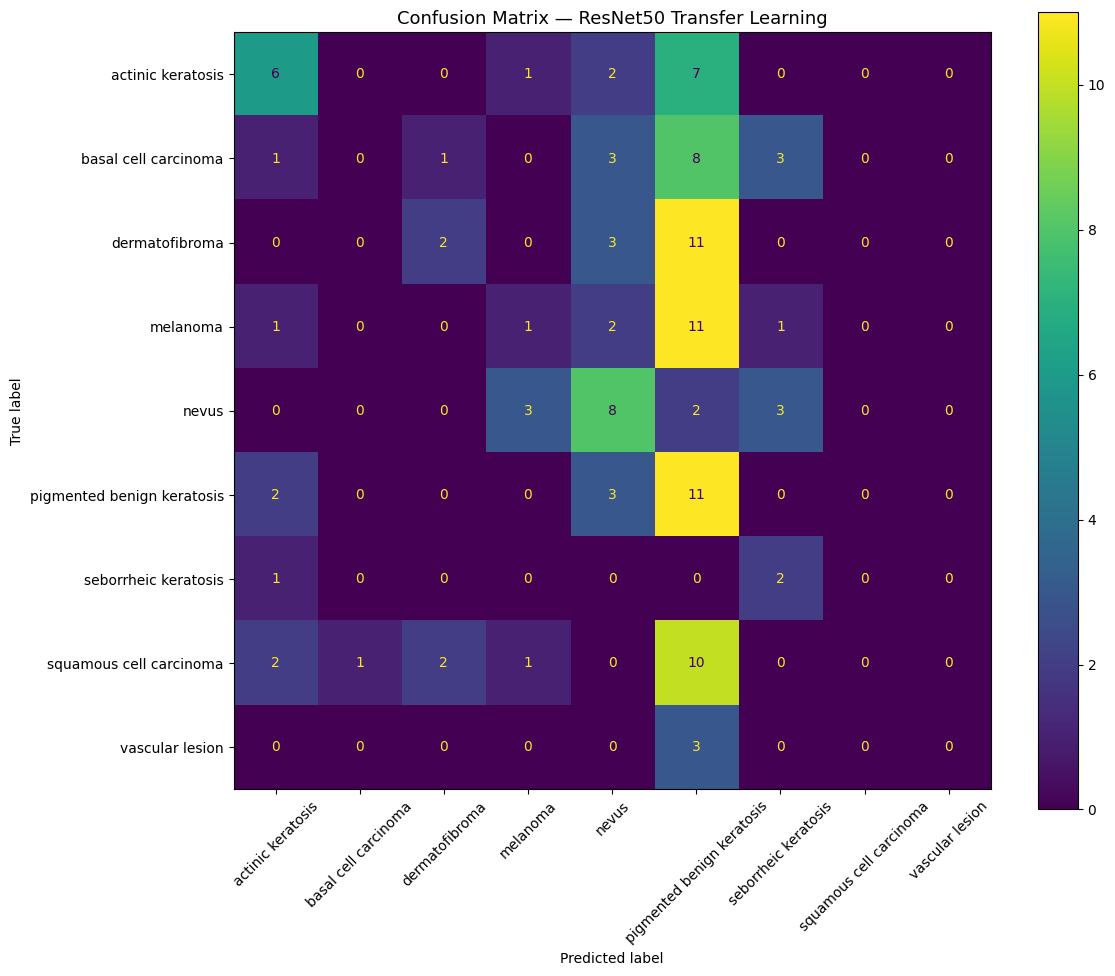

In [38]:
fig, ax = plt.subplots(figsize=(12, 10))
cm   = confusion_matrix(true_labels, transfer_pred_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=class_names)
disp.plot(ax=ax, xticks_rotation=45, colorbar=True)
ax.set_title('Confusion Matrix — ResNet50 Transfer Learning', fontsize=13)
plt.tight_layout()
plt.savefig('transfer_confusion_matrix.png', dpi=150)
plt.show()

Cell -28: Sample predictions — Transfer Learning

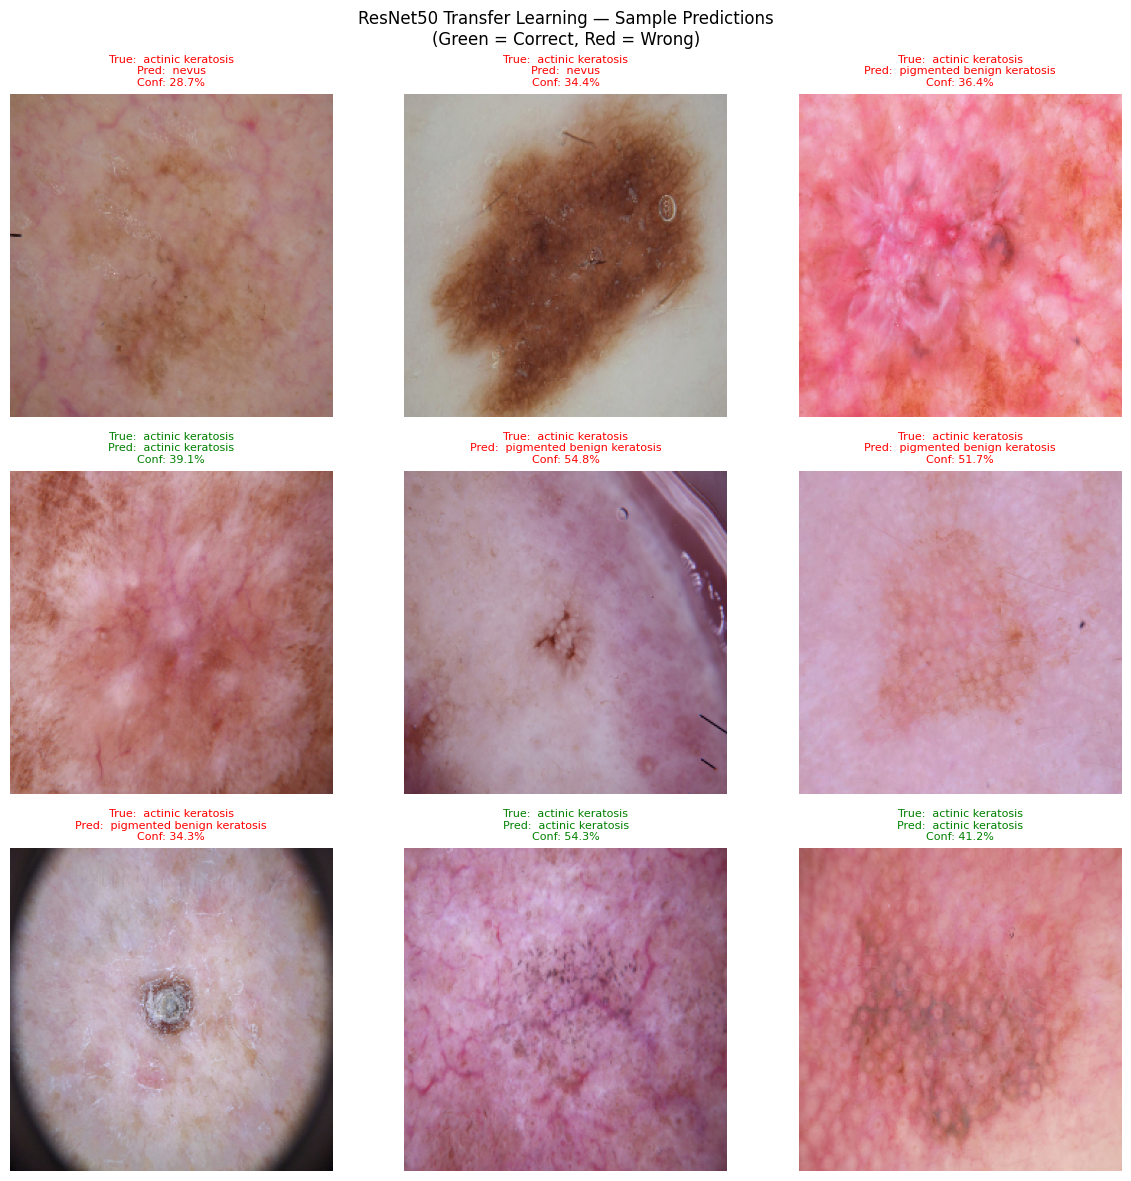

In [39]:
# Cell 28: Sample predictions — Transfer Learning
test_generator.reset()
images, labels = next(test_generator)

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten()

for i in range(9):
    img      = images[i]
    true_idx = np.argmax(labels[i])
    pred_probs = transfer_model.predict(img.reshape(1, 224, 224, 3), verbose=0)
    pred_idx   = np.argmax(pred_probs)
    confidence = np.max(pred_probs) * 100

    axes[i].imshow(img)
    color = 'green' if pred_idx == true_idx else 'red'
    axes[i].set_title(
        f"True:  {class_names[true_idx]}\n"
        f"Pred:  {class_names[pred_idx]}\n"
        f"Conf: {confidence:.1f}%",
        fontsize=8, color=color
    )
    axes[i].axis('off')

plt.suptitle('ResNet50 Transfer Learning — Sample Predictions\n(Green = Correct, Red = Wrong)',
             fontsize=12)
plt.tight_layout()
plt.savefig('transfer_sample_predictions.png', dpi=150)
plt.show()

Cell 29 — Final Comparison: All Models Side-by-Side

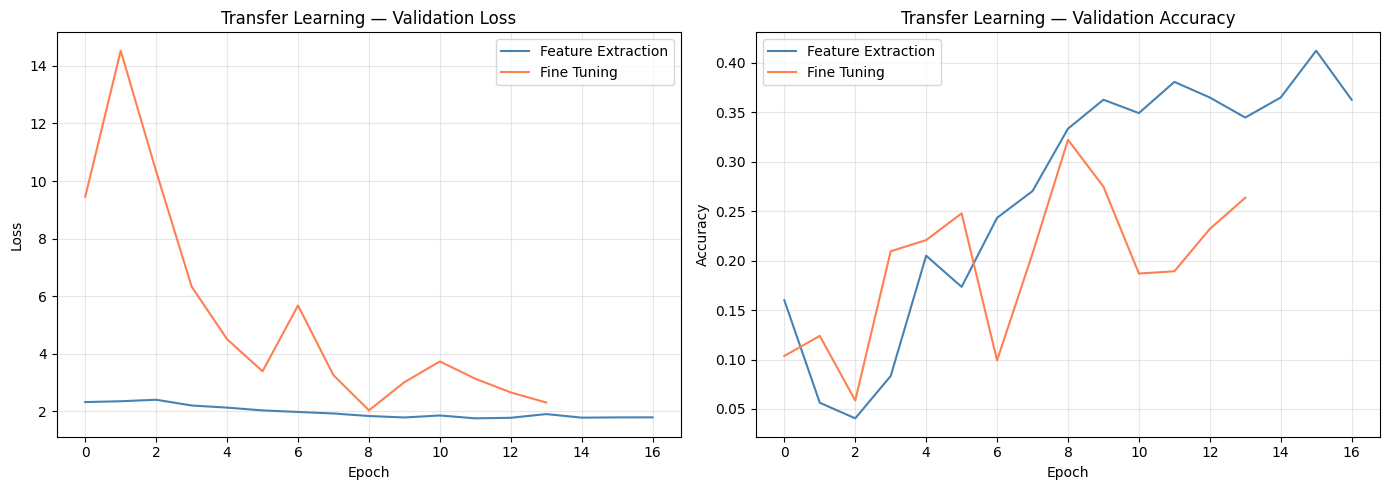

FINAL MODEL COMPARISON SUMMARY
Model                               Best Val Acc   Train Time
-----------------------------------------------------------------
Baseline CNN                              40.32%        5.32m
Deeper CNN (Adam)                         17.79%        8.05m
Deeper CNN (SGD)                          27.03%       10.51m
Ablation (No Dropout)                     45.27%       17.15m
ResNet50 Transfer Learning                32.21%       23.97m


In [40]:
# Plot feature extraction vs fine tuning curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Validation Loss comparison
axes[0].plot(feature_extraction_history.history['val_loss'],
             label='Feature Extraction', color='steelblue')
axes[0].plot(finetune_history.history['val_loss'],
             label='Fine Tuning', color='coral')
axes[0].set_title('Transfer Learning — Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Validation Accuracy comparison
axes[1].plot(feature_extraction_history.history['val_accuracy'],
             label='Feature Extraction', color='steelblue')
axes[1].plot(finetune_history.history['val_accuracy'],
             label='Fine Tuning', color='coral')
axes[1].set_title('Transfer Learning — Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('transfer_learning_curves.png', dpi=150)
plt.show()

# Final comparison summary — dynamic values from training
print("=" * 65)
print("FINAL MODEL COMPARISON SUMMARY")
print("=" * 65)
print(f"{'Model':<35} {'Best Val Acc':>12} {'Train Time':>12}")
print("-" * 65)
print(f"{'Baseline CNN':<35} {max(baseline_history.history['val_accuracy'])*100:>11.2f}% {baseline_train_time/60:>11.2f}m")
print(f"{'Deeper CNN (Adam)':<35} {max(deeper_history.history['val_accuracy'])*100:>11.2f}% {deeper_train_time/60:>11.2f}m")
print(f"{'Deeper CNN (SGD)':<35} {max(sgd_history.history['val_accuracy'])*100:>11.2f}% {sgd_train_time/60:>11.2f}m")
print(f"{'Ablation (No Dropout)':<35} {max(ablation_history.history['val_accuracy'])*100:>11.2f}% {ablation_train_time/60:>11.2f}m")
print(f"{'ResNet50 Transfer Learning':<35} {max(finetune_history.history['val_accuracy'])*100:>11.2f}% {(feature_extraction_time+finetune_time)/60:>11.2f}m")
print("=" * 65)